In [1]:
!pip install --upgrade mysql-connector-python


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pip install mysql.connector

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
def make_connection_with_db():
    import mysql.connector

    connection_mydb = mysql.connector.connect(
    host='localhost',
    port=3360,
    user='root',
    password='',
    database='wp_ecommerce')

    cursor = connection_mydb.cursor(dictionary=True)
    return connection_mydb,cursor

In [5]:
def get_users_profiles():
    df = pd.DataFrame(columns=['user_id','country','age','gender'])
    _,cursor = make_connection_with_db()

    sql='SELECT ID FROM wp_users'

    cursor.execute(sql)

    users_results = cursor.fetchall()

    for user in users_results:
        user_id = user['ID']

        sql = "SELECT meta_value FROM wp_usermeta WHERE user_id=(%s) and meta_key='country'"

        param = (user_id, )

        cursor.execute(sql, param)

        result = cursor.fetchall()

        if result != None and len(result) > 0:
            country = result[0]['meta_value']

        else:
            country='Unknown'

        sql = "SELECT meta_value FROM wp_usermeta WHERE user_id=(%s) and meta_key='age'"

        param = (user_id, )

        cursor.execute(sql, param)

        result = cursor.fetchall()

        if result != None and len(result) > 0:
            age = result[0]['meta_value']

        else:
            age='Unknown'

        sql = "SELECT meta_value FROM wp_usermeta WHERE  user_id=(%s) and meta_key='gender'"

        param = (user_id, )

        cursor.execute(sql, param)

        result = cursor.fetchall()

        if result != None and len(result) > 0:
            gender = result[0]['meta_value']

        else:
            gender='Unknown'

        obj = {
            'user_id':[user['ID']],
            'country':[country],
            'age':[age],
            'gender':[gender],
        }

        df_obj = pd.DataFrame(obj)

        df = pd.concat([df,df_obj], ignore_index=True)

    df = df.drop(df[df['country']=='Unknown'].index)
    df = df.drop(df[df['age']=='Unknown'].index)
    df = df.drop(df[df['gender']=='Unknown'].index)

    df['age']=pd.to_numeric(df['age'])

    return df

            

In [6]:
df_profile = get_users_profiles()
df_profile

,user_id,country,age,gender
0,1,SA,36,انثى
1,2,JO,48,انثى
2,3,KW,40,ذكر
3,4,AE,24,ذكر
4,5,JO,35,انثى
...,...,...,...,...
1497,1498,SA,49,انثى
1498,1499,SA,25,انثى
1499,1500,SA,22,انثى
1500,1501,JO,33,ذكر


In [7]:
def show_users_age_his():
    df_profile = get_users_profiles()

    df_age = df_profile['age']

    df_age.hist(bins=[0,10,20,30,40,50,60,70,80])

    plt.xlabel("Age")

    plt.ylabel("Count")

    plt.title("Users Age Histogram")
    plt.show()

    

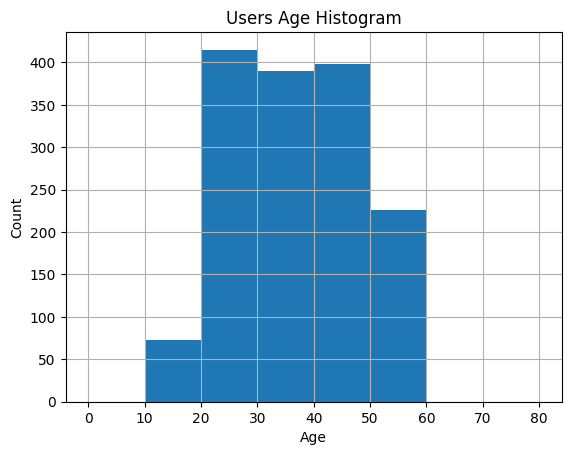

In [8]:
show_users_age_his()

In [9]:
def show_users_get_density():

    df_profile = get_users_profiles()

    df_age = df_profile['age']

    df_age.plot(kind='density')

    plt.xlabel("Age")

    plt.ylabel("Density")

    plt.title("Users Age Density")
    plt.show()

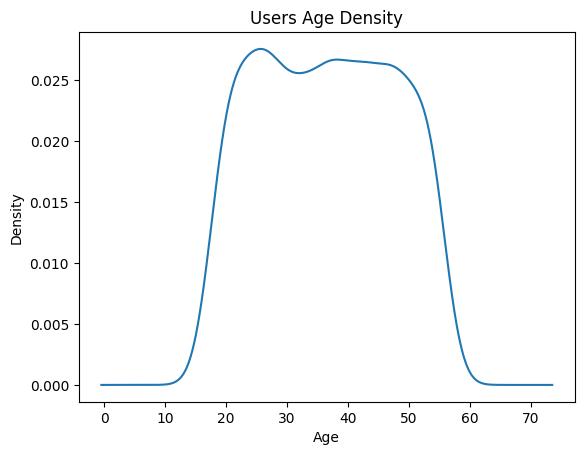

In [10]:
show_users_get_density()

In [11]:
pip install arabic-reshaper

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
pip install python-bidi

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
def show_users_gender_pie():
    df_profile = get_users_profiles()

    df_gender = df_profile[['gender', 'user_id']].groupby('gender').count()
    print(df_gender)

    import arabic_reshaper
    from bidi.algorithm import get_display

    df_gender = df_gender.reset_index()

    print(df_gender)

    df_gender['gender'] = df_gender['gender'].apply(lambda a: get_display(arabic_reshaper.reshape(a)))

    plt.pie(df_gender['user_id'], labels = df_gender['gender'], autopct='%1.1f%%')

    plt.title('Gender Pie')

    plt.show()

        user_id
gender         
انثى        784
ذكر         718
  gender  user_id
0   انثى      784
1    ذكر      718


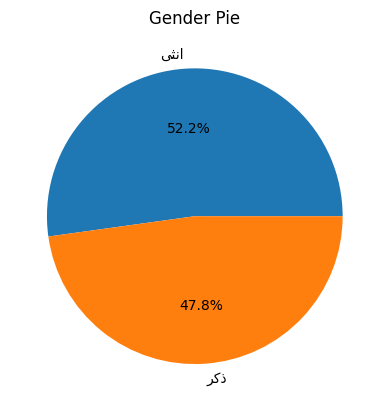

In [14]:
show_users_gender_pie()

In [15]:
def show_users_gender_countplot():

    import arabic_reshaper
    from bidi.algorithm import get_display

    df_profile = get_users_profiles()

    plt.subplots(figsize=(8, 6))

    plt.title("Users Gender Count")

    df_profile['gender'] = df_profile['gender'].apply(lambda a: get_display(arabic_reshaper.reshape(a)))

    ax = sns.countplot(x=df_profile['gender'])

    ax.bar_label(ax.containers[0])

    plt.show()

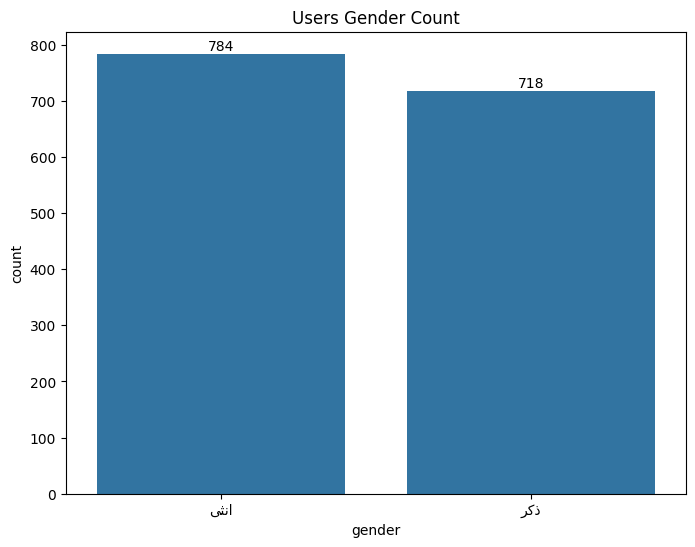

In [16]:
show_users_gender_countplot()